In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure

set_plot_style()

In [2]:
DATA_PATH = "../data/raw/divar.csv"

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

In [4]:
df[["created_at_month", "rent_value"]].isna().sum()

created_at_month         0
rent_value          648678
dtype: int64

In [5]:
df["created_at_month"].value_counts().sort_index()

created_at_month
2020-02-01 00:00:00         1
2020-12-01 00:00:00         1
2021-02-01 00:00:00         1
2021-05-01 00:00:00         1
2021-06-01 00:00:00         1
2021-11-01 00:00:00         1
2021-12-01 00:00:00         2
2022-01-01 00:00:00         1
2022-02-01 00:00:00         2
2022-03-01 00:00:00         1
2022-04-01 00:00:00         5
2022-05-01 00:00:00         7
2022-06-01 00:00:00         4
2022-07-01 00:00:00         4
2022-08-01 00:00:00         9
2022-09-01 00:00:00         6
2022-10-01 00:00:00         6
2022-11-01 00:00:00         9
2022-12-01 00:00:00        11
2023-01-01 00:00:00        17
2023-02-01 00:00:00        17
2023-03-01 00:00:00        25
2023-04-01 00:00:00        23
2023-05-01 00:00:00        53
2023-06-01 00:00:00        66
2023-07-01 00:00:00        96
2023-08-01 00:00:00       117
2023-09-01 00:00:00       177
2023-10-01 00:00:00       213
2023-11-01 00:00:00       353
2023-12-01 00:00:00       532
2024-01-01 00:00:00       942
2024-02-01 00:00:00    

In [6]:
df["created_at_month"].unique()

<StringArray>
['2024-08-01 00:00:00', '2024-05-01 00:00:00', '2024-10-01 00:00:00',
 '2024-06-01 00:00:00', '2024-09-01 00:00:00', '2024-11-01 00:00:00',
 '2024-07-01 00:00:00', '2024-12-01 00:00:00', '2024-04-01 00:00:00',
 '2025-01-01 00:00:00', '2024-03-01 00:00:00', '2024-01-01 00:00:00',
 '2025-02-01 00:00:00', '2024-02-01 00:00:00', '2023-11-01 00:00:00',
 '2023-09-01 00:00:00', '2023-10-01 00:00:00', '2023-07-01 00:00:00',
 '2023-12-01 00:00:00', '2023-05-01 00:00:00', '2023-03-01 00:00:00',
 '2023-04-01 00:00:00', '2023-06-01 00:00:00', '2023-08-01 00:00:00',
 '2023-02-01 00:00:00', '2021-05-01 00:00:00', '2022-11-01 00:00:00',
 '2022-07-01 00:00:00', '2022-05-01 00:00:00', '2022-06-01 00:00:00',
 '2023-01-01 00:00:00', '2022-10-01 00:00:00', '2021-12-01 00:00:00',
 '2020-12-01 00:00:00', '2022-12-01 00:00:00', '2022-04-01 00:00:00',
 '2022-09-01 00:00:00', '2022-08-01 00:00:00', '2021-06-01 00:00:00',
 '2022-02-01 00:00:00', '2020-02-01 00:00:00', '2022-01-01 00:00:00',
 '2025

In [8]:
trend_df = df[["created_at_month", "rent_value"]].copy()

trend_df["created_at_month"] = pd.to_datetime(trend_df["created_at_month"])

In [9]:
trend_df.dtypes

created_at_month    datetime64[us]
rent_value                 float64
dtype: object

In [10]:
trend_df = trend_df.dropna(subset=["rent_value"])

In [11]:
monthly_avg = trend_df.groupby("created_at_month")["rent_value"].mean().reset_index()

In [12]:
monthly_avg.head()

,created_at_month,rent_value
0,2022-06-01,3.503333e+07
1,2022-07-01,4.500000e+07
2,2022-08-01,7.000000e+07
3,2023-07-01,0.000000e+00
4,2023-08-01,6.500000e+07


In [13]:
import jdatetime


def to_jalali_label(date):
    jdate = jdatetime.date.fromgregorian(date=date.date())

    month_names = [
        "فروردین",
        "اردیبهشت",
        "خرداد",
        "تیر",
        "مرداد",
        "شهریور",
        "مهر",
        "آبان",
        "آذر",
        "دی",
        "بهمن",
        "اسفند",
    ]

    return f"{month_names[jdate.month-1]} {jdate.year}"

In [14]:
monthly_avg["jalali_month"] = monthly_avg["created_at_month"].apply(to_jalali_label)

In [36]:
monthly_avg["jalali_month"] = monthly_avg["jalali_month"].apply(fa)

✅ Figure saved to: D:\Quera\Exercises\project01\divar-real-estate-ml\reports\figures\average_rent_trend.png


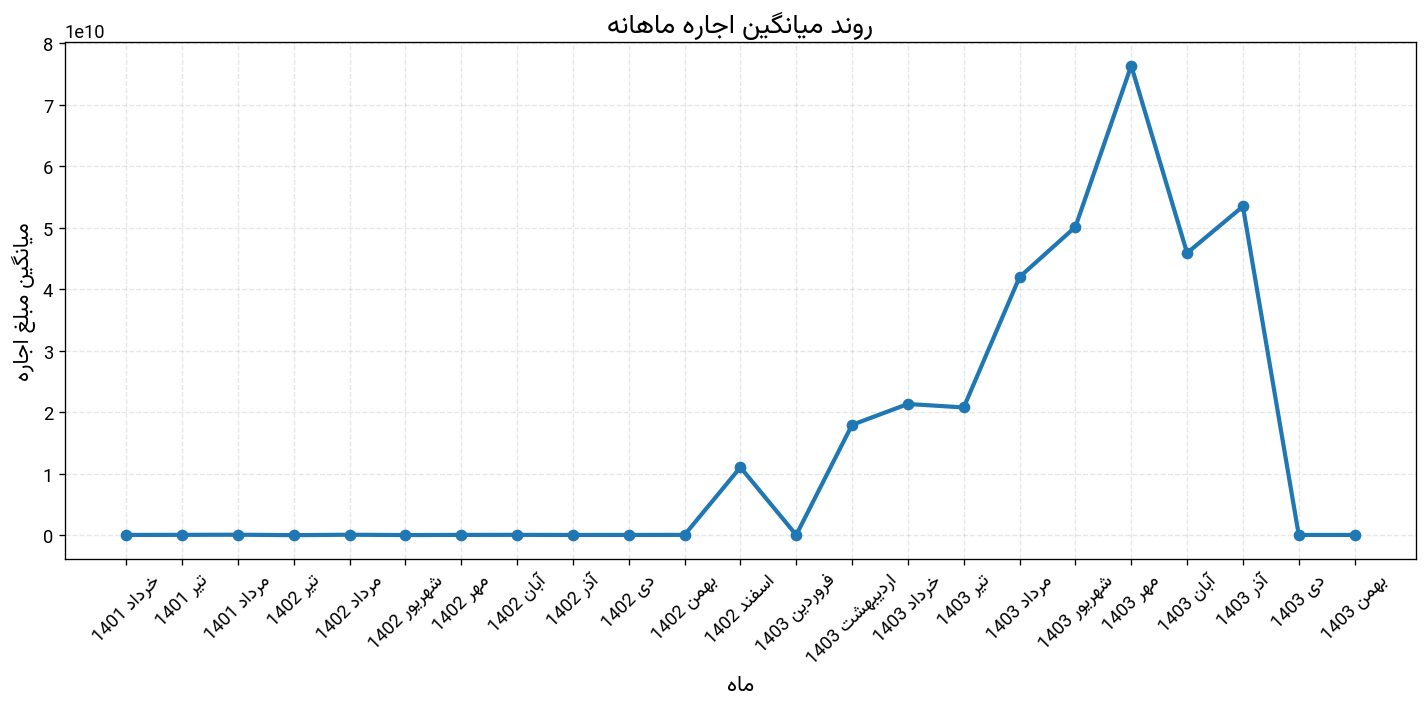

In [37]:
plt.figure()

plt.plot(monthly_avg["jalali_month"], monthly_avg["rent_value"], marker="o", color=COLORS["trend"],)

plt.title(fa("روند میانگین اجاره ماهانه"))

plt.xlabel(fa("ماه"))

plt.ylabel(fa("میانگین مبلغ اجاره"))

plt.xticks(rotation=45)

plt.tight_layout()

save_figure("average_rent_trend")

plt.show()

<p dir="rtl">

میانگین اجاره بها به طور کلی با گذشت زمان افزایش می‌یابد و روند صعودی قابل توجهی در دوره اصلی مشاهده در سال ۲۰۲۴ دارد. ماه‌های اولیه و پایانی در مجموعه داده‌ها حاوی آگهی نسبتاً کمی هستند، بنابراین میانگین آنها ممکن است به طور دقیق بازار را نشان ندهد. بنابراین، روند مشاهده شده در دوره متراکم ۲۰۲۴، دیدگاه قابل اعتمادتری از تغییرات قیمت اجاره ارائه می‌دهد.

</p>